<a href="https://colab.research.google.com/github/Lio72rga/Mineria-de-Datos-2026/blob/main/Notebook_4_Ejercicio_Integrador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 4 - Ejercicio Integrador

## Predicción de Reclamos en Seguros

Autor: Lionel Martinez

Materia Mineria de Datos - 2026

# Introducción

En este ejercicio integrador aplicaremos técnicas de aprendizaje supervisado utilizando:

- Regresión Logística
- Regresión Múltiple

El objetivo será analizar datos de clientes de una aseguradora para:

1. Predecir si un cliente realizará un reclamo.
2. Estimar el monto del reclamo.

Variables utilizadas:
- Edad
- Ingresos
- Historial de Accidentes

Variables objetivo:
- Reclamo (0 = No, 1 = Sí)
- Monto del Reclamo

In [11]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    r2_score,
    mean_squared_error,
    mean_absolute_error
)


In [12]:

data = {
    "Edad":[25,40,32,50,28,45],
    "Ingresos":[30000,55000,42000,60000,37000,52000],
    "Historial_Accidentes":[1,0,1,0,1,0],
    "Monto_Reclamo":[5000,0,7500,0,6500,0],
    "Reclamo":[1,0,1,0,1,0]
}

df = pd.DataFrame(data)

X = df[["Edad","Ingresos","Historial_Accidentes"]]

# Clasificación
y_c = df["Reclamo"]

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X, y_c, test_size=0.2, random_state=42
)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_tr_c, y_tr_c)

y_pred_c = log_model.predict(X_te_c)

print("Accuracy:", accuracy_score(y_te_c, y_pred_c))
print(confusion_matrix(y_te_c, y_pred_c))

# Regresión
y_r = df["Monto_Reclamo"]

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X, y_r, test_size=0.2, random_state=42
)

reg_model = LinearRegression()
reg_model.fit(X_tr_r, y_tr_r)

y_pred_r = reg_model.predict(X_te_r)

print("R²:", r2_score(y_te_r, y_pred_r))
print("MSE:", mean_squared_error(y_te_r, y_pred_r))
print("MAE:", mean_absolute_error(y_te_r, y_pred_r))


Accuracy: 1.0
[[1 0]
 [0 1]]
R²: -4.69346938775507
MSE: 35584183.673469186
MAE: 5464.285714285702


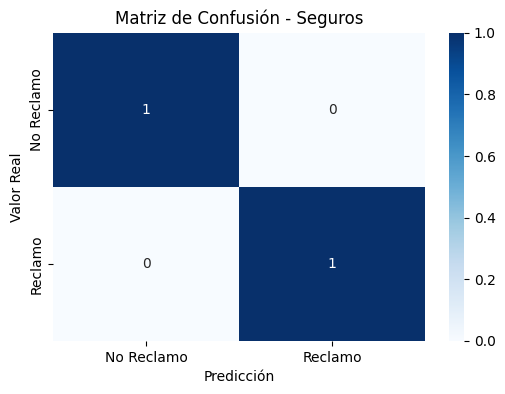

In [13]:
cm = confusion_matrix(y_te_c, y_pred_c)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["No Reclamo","Reclamo"],
            yticklabels=["No Reclamo","Reclamo"])

plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión - Seguros")

plt.show()

Gráfico Real vs Predicho

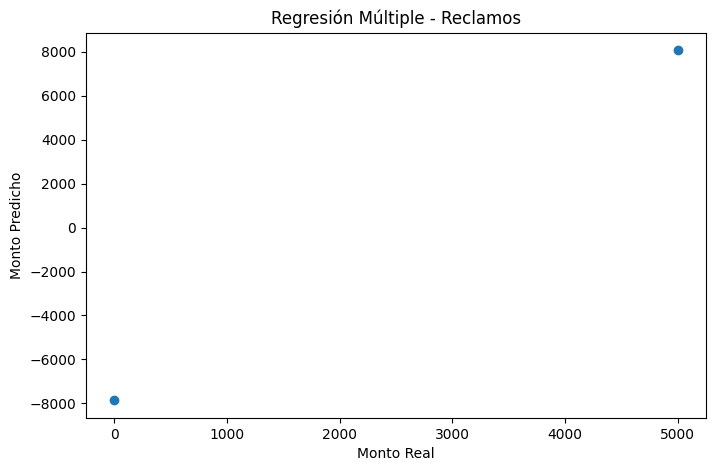

In [14]:
plt.figure(figsize=(8,5))

plt.scatter(y_te_r, y_pred_r)

plt.xlabel("Monto Real")
plt.ylabel("Monto Predicho")

plt.title("Regresión Múltiple - Reclamos")

plt.show()

Interpretación Regresión

# Interpretación - Regresión Múltiple

## R²
Indica qué porcentaje de la variabilidad del monto de reclamo puede explicar el modelo.

## MSE
Mide el error cuadrático promedio.

## MAE
Representa el error absoluto promedio entre valores reales y predichos.

# Comparación entre Modelos

## Regresión Logística
- Predice categorías.
- Se utiliza para clasificación.
- En este caso: Reclamo o No Reclamo.

## Regresión Múltiple
- Predice valores continuos.
- Se utiliza para regresión.
- En este caso: monto del reclamo.

# Interacción con IA

Consulta realizada:

"Tengo un dataset de aseguradoras. ¿Qué estrategias de modelado recomendarías para predecir el monto de un reclamo?"

Respuesta obtenida:
- Utilizar modelos de regresión.
- Incorporar más variables predictoras.
- Aplicar validación cruzada.
- Analizar posibles problemas de overfitting.
- Evaluar escalado y selección de variables.

# Conclusión

En este ejercicio integrador se aplicaron modelos de Regresión Logística y Regresión Múltiple sobre un dataset de seguros.

La Regresión Logística permitió clasificar clientes según la probabilidad de realizar reclamos, mientras que la Regresión Múltiple permitió estimar el monto económico de dichos reclamos.

Las métricas y visualizaciones facilitaron la interpretación del desempeño de ambos modelos.

Este trabajo permitió integrar conceptos fundamentales de aprendizaje supervisado aplicados a un caso realista de análisis de datos.